In [1]:
!pip -q install pandas numpy matplotlib seaborn statsmodels openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.multitest import multipletests

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
tests = pd.DataFrame({
    "network": ["DMN", "Salience", "FPN", "Limbic", "Visual", "Somatomotor"],
    "p_value": [0.001, 0.012, 0.028, 0.061, 0.084, 0.140]
})

tests

,network,p_value
0,DMN,0.001
1,Salience,0.012
2,FPN,0.028
3,Limbic,0.061
4,Visual,0.084
5,Somatomotor,0.140


In [4]:
tests["sig_uncorrected"] = tests["p_value"] < 0.05

_, fdr_p, _, _ = multipletests(
    tests["p_value"],
    method="fdr_bh"
)

tests["fdr_p"] = fdr_p
tests["sig_fdr"] = tests["fdr_p"] < 0.05

tests

,network,p_value,sig_uncorrected,fdr_p,sig_fdr
0,DMN,0.001,True,0.0060,True
1,Salience,0.012,True,0.0360,True
2,FPN,0.028,True,0.0560,False
3,Limbic,0.061,False,0.0915,False
4,Visual,0.084,False,0.1008,False
5,Somatomotor,0.140,False,0.1400,False


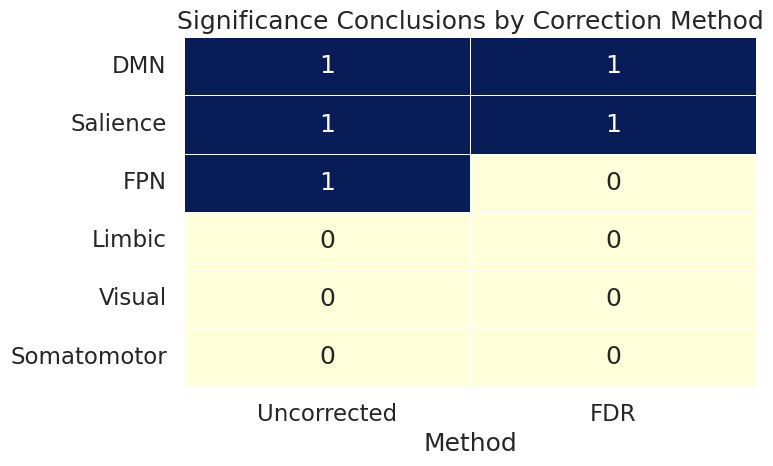

In [10]:
sig_matrix = tests.set_index("network")[["sig_uncorrected", "sig_fdr"]].astype(int)
sig_matrix.columns = ["Uncorrected", "FDR"]

plt.figure(figsize=(8,5))

sns.heatmap(
    sig_matrix,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

plt.xlabel("Method")
plt.ylabel("")
plt.title("Significance Conclusions by Correction Method")
plt.tight_layout()
plt.savefig("figures/04_inference_sensitivity.png", dpi=300)
plt.show()

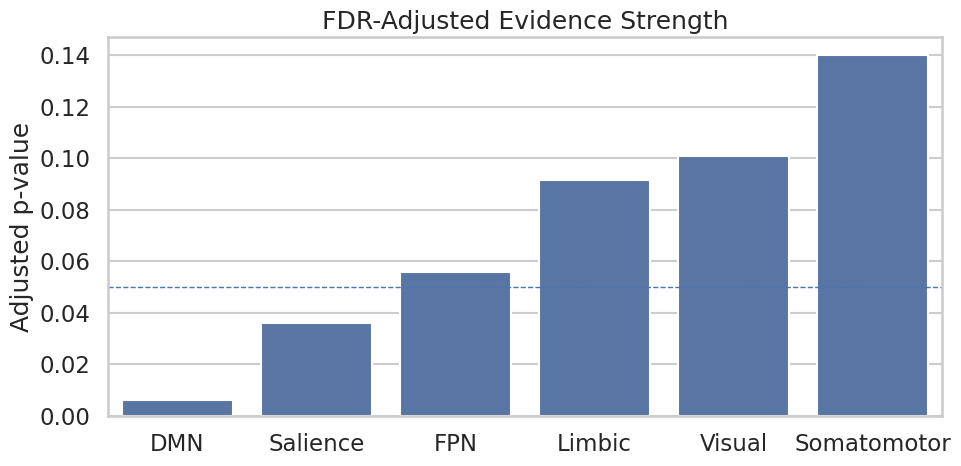

In [6]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=tests,
    x="network",
    y="fdr_p"
)

plt.axhline(0.05, linestyle="--", linewidth=1)
plt.xlabel("")
plt.ylabel("Adjusted p-value")
plt.title("FDR-Adjusted Evidence Strength")
plt.tight_layout()
plt.savefig("figures/04_fdr_values.png", dpi=300)
plt.show()

In [7]:
tests.to_csv("outputs/04_inference_results.csv", index=False)

tests

,network,p_value,sig_uncorrected,fdr_p,sig_fdr
0,DMN,0.001,True,0.0060,True
1,Salience,0.012,True,0.0360,True
2,FPN,0.028,True,0.0560,False
3,Limbic,0.061,False,0.0915,False
4,Visual,0.084,False,0.1008,False
5,Somatomotor,0.140,False,0.1400,False
